Objective: Load preprocessed 3D EEG epoch tensor $X \in \mathbb{R}^{N \times 64 \times 641}$ and binary target vector $y \in \{0, 1\}^N$.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import mne
from scipy import linalg
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [2]:
sys.path

['/opt/pyenv/versions/3.13.1/lib/python313.zip',
 '/opt/pyenv/versions/3.13.1/lib/python3.13',
 '/opt/pyenv/versions/3.13.1/lib/python3.13/lib-dynload',
 '',
 '/home/jvalenci/Desktop/Total-Perspective-Vortex/.env/lib/python3.13/site-packages',
 '/home/jvalenci/Desktop/Total-Perspective-Vortex/srcs']

In [3]:
# abspath returns of a given relative path
lMiscPath = os.path.abspath('../srcs')

In [4]:

# Add source directory to path to access local modules
if lMiscPath not in sys.path:
    sys.path.append(os.path.abspath('../srcs'))

from misc import load_and_parse_eeg


In [5]:
# Suppress verbose MNE logs for clarity
mne.set_log_level('WARNING')

# 1. Configuration: 102-Subject Benchmark Cohort
BASE_DATA_PATH = "mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0"
ANOMALY_EXCLUDED_SUBJECTS = [38, 88, 89, 92, 100, 104, 106]
CLEAN_SUBJECTS = [s for s in range(1, 110) if s not in ANOMALY_EXCLUDED_SUBJECTS]
RUN_IDS = [4, 8, 12]  # Unilateral Motor Imagery: Left vs. Right Fist

In [6]:
# 2. Data Ingestion
X, y, df_metadata = load_and_parse_eeg(
    subject_ids=CLEAN_SUBJECTS,
    run_ids=RUN_IDS,
    base_path=BASE_DATA_PATH,
    tmin=0.0,
    tmax=4.0,
    include_rest=False
)

# 3. Input Verification & Visual Inspection
print(f"X Type: {type(X)} | Shape: {X.shape} | Dtype: {X.dtype}")
print(f"y Type: {type(y)} | Shape: {y.shape} | Dtype: {y.dtype}")
print(f"Target Class Counts: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Signal Statistics: Min={X.min():.2e}, Max={X.max():.2e}, Mean={X.mean():.2e}, Std={X.std():.2e}")

Processing Subjects:   0%|          | 0/102 [00:00<?, ?it/s]

Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.
Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.
Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.
Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.
Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R08.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.
Loading data from mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R12.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 mon

#### **Objective:**  This mesures how nodes interact with each other during each type of thinking task (e.g., left hand vs right hand motor imagery) by using the covariance matrices of the EEG signals.

* The covariance matrices are computed for each trial and then averaged across trials for each class. The resulting mean covariance matrices are then normalized to ensure that they have unit trace, which is a common practice in EEG analysis to facilitate comparison between different conditions.

* Compute normalized mean spatial covariance matrices $\Sigma_0, \Sigma_1 \in \mathbb{R}^{64 \times 64}$ for Class 0 ($y=0$) and Class 1 ($y=1$) from input trials $X_i \in \mathbb{R}^{64 \times 641}$.

for deep understanding see the following references:

https://app.notion.com/p/jvalenci/total-perspective-vortex-3929d52658e080088fdcc42b60719b01?source=copy_link#3e69d52658e080ec9aefd5f088a1cd80

In [7]:
# 1. Trial-wise Normalized Covariance Estimation: Sigma = (X * X.T) / trace(X * X.T)
def compute_class_covariances(X, y):
    """Computes mean normalized spatial covariance for each binary class."""
    covs = []
    for target in [0, 1]:
        # !Filter trials for specific class
        # e.g., X_class shape: (N_trials_class, C, T)
        # data structure y is a 1D array of shape (N_trials,) containing class labels
        X_class = X[y == target]

        # Batch compute covariance for each trial: (N_trials, C, T) -> (N_trials, C, C)
        # Using np.matmul for trial-wise dot product: X_i @ X_i.T
        trial_covs = np.matmul(X_class, X_class.transpose(0, 2, 1))

        # Normalize each trial covariance by its trace to ensure unit variance across sensors
        # np.einsum provides a efficient way to extract the diagonal and sum for batch trace
        traces = np.einsum("ijj->i", trial_covs)
        normalized_trial_covs = trial_covs / traces[:, np.newaxis, np.newaxis]

        # Average across trials to get class-conditional mean covariance
        covs.append(np.mean(normalized_trial_covs, axis=0))
    return covs[0], covs[1]


Sigma_0, Sigma_1 = compute_class_covariances(X, y)

# 2. Statistical Verification & Symmetry Check
print(f"Sigma_0 Shape: {Sigma_0.shape} | Sigma_1 Shape: {Sigma_1.shape}")
print(f"Sigma_0 Dtype: {Sigma_0.dtype} | Sigma_1 Dtype: {Sigma_1.dtype}")
print(
    f"Symmetry Check (Max Diff Σ - Σ.T): Class 0 = {np.max(np.abs(Sigma_0 - Sigma_0.T)):.2e}, Class 1 = {np.max(np.abs(Sigma_1 - Sigma_1.T)):.2e}"
)
print(
    f"Trace Verification (Should be 1.0): Class 0 = {np.trace(Sigma_0):.2f}, Class 1 = {np.trace(Sigma_1):.2f}"
)

Sigma_0 Shape: (64, 64) | Sigma_1 Shape: (64, 64)
Sigma_0 Dtype: float64 | Sigma_1 Dtype: float64
Symmetry Check (Max Diff Σ - Σ.T): Class 0 = 0.00e+00, Class 1 = 0.00e+00
Trace Verification (Should be 1.0): Class 0 = 1.00, Class 1 = 1.00


Objective: Solve the generalized eigenvalue problem $\Sigma_0 v = \lambda (\Sigma_0 + \Sigma_1) v$ to extract spatial filters $V \in \mathbb{R}^{64 \times 64}$ and eigenvalues $\lambda \in \mathbb{R}^{64}$.

In [ ]:
# 1. Apply Regularization (Shrinkage) before solving GEP
# This prevents LinAlgError: "B is not positive definite"
alpha = 1e-6
Sigma_0_reg = (1 - alpha) * Sigma_0 + alpha * np.eye(Sigma_0.shape[0])
Sigma_1_reg = (1 - alpha) * Sigma_1 + alpha * np.eye(Sigma_1.shape[0])

# 2. Solve the Generalized Eigenvalue Problem (GEP)
# Sigma_0_reg * v = lambda * (Sigma_0_reg + Sigma_1_reg) * v
eigenvalues, eigenvectors = linalg.eigh(Sigma_0_reg, Sigma_0_reg + Sigma_1_reg)

# 3. Visual Inspection of Eigen-structure
print(f"Eigenvalues Array Shape: {eigenvalues.shape}")
print(f"Eigenvectors Matrix (V) Shape: {eigenvectors.shape}")
print(f"Eigenvalue range: [{eigenvalues.min():.4f}, {eigenvalues.max():.4f}] (Expected: [0, 1])")
print(f"Top 3 Eigenvalues (Class 0 discriminants): {eigenvalues[-3:]}")
print(f"Bottom 3 Eigenvalues (Class 1 discriminants): {eigenvalues[:3]}")

# 4. Statistical Sanity Check: Condition Number
cond_sum = np.linalg.cond(Sigma_0_reg + Sigma_1_reg)
print(f"Matrix Condition Number (Sigma_sum): {cond_sum:.2e}")

Eigenvalues Array Shape: (64,)
Eigenvectors Matrix (V) Shape: (64, 64)
Eigenvalue range: [0.4424, 1.4570] (Expected: [0, 1])
Top 3 Eigenvalues (Class 0 discriminants): [0.53544124 0.5564361  1.45701357]
Bottom 3 Eigenvalues (Class 1 discriminants): [0.44244261 0.46871857 0.47088172]
Matrix Condition Numbers: Sigma_0 = 3.14e+16, Sigma_sum = 5.31e+16


Objective: Select $m=3$ components per class to construct spatial filter matrix $W \in \mathbb{R}^{64 \times 6}$ and project $X \to X_{CSP} \in \mathbb{R}^{N \times 6}$.

In [9]:
# 1. Component Selection (m=3)
# eigh returns eigenvalues in ascending order.
# Smallest eigenvalues (indices 0, 1, 2) maximize variance for Class 1.
# Largest eigenvalues (indices -1, -2, -3) maximize variance for Class 0.
m = 3
ix = np.concatenate([np.arange(m), np.arange(-m, 0)])
W = eigenvectors[:, ix]

# 2. Manual Spatial Projection: Z = W.T * X
# X shape: (N, C, T) -> W.T shape: (6, C) -> Z shape: (N, 6, T)
Z = np.matmul(W.T, X)

# 3. Manual Feature Extraction: Log-Variance
# Calculate variance along time axis (axis=2), then take log
epsilon = 1e-10
feat_manual = np.log(np.var(Z, axis=2) + epsilon)

# 4. Visual Verification
print(f"Spatial Filter Matrix W Shape: {W.shape}")
print(f"Projected Signal Z Shape: {Z.shape}")
print(f"Final Manual Feature Matrix Shape: {feat_manual.shape} (Expected: ({len(y)}, 6))")
print(f"Feature Stats: Mean={feat_manual.mean():.2f}, Std={feat_manual.std():.2f}")
print(f"Class 0 Mean Features: {feat_manual[y==0].mean(axis=0)}")
print(f"Class 1 Mean Features: {feat_manual[y==1].mean(axis=0)}")

Spatial Filter Matrix W Shape: (64, 6)
Projected Signal Z Shape: (4571, 6, 641)
Final Manual Feature Matrix Shape: (4571, 6) (Expected: (4571, 6))
Feature Stats: Mean=-20.23, Std=1.74
Class 0 Mean Features: [-19.6794047  -19.83951405 -19.64846627 -19.72562736 -19.53460549
 -23.02585093]
Class 1 Mean Features: [-19.48867308 -19.71960862 -19.53055961 -19.82345569 -19.68781456
 -23.02585093]


Objective: Encapsulate the linear algebra into a custom Scikit-Learn transformer inheriting from `BaseEstimator` and `TransformerMixin`.

In [ ]:
class CustomCSP(BaseEstimator, TransformerMixin):
    """
    Custom Common Spatial Patterns (CSP) Transformer.
    Calculates spatial filters to maximize variance for one class vs another.
    """
    def __init__(self, n_components=6, reg=1e-6, log=True):
        self.n_components = n_components
        self.reg = reg
        self.log = log
        self.filters_ = None

    def fit(self, X, y):
        # 1. Compute Class Covariances (using the logic from Step 1)
        Sigma_0, Sigma_1 = compute_class_covariances(X, y)
        
        # 2. Regularization (Shrinkage): Sigma = (1-alpha)*Sigma + alpha*I
        # This ensures the matrices are positive definite and well-conditioned
        if self.reg is not None and self.reg > 0:
            C = Sigma_0.shape[0]
            Sigma_0 = (1 - self.reg) * Sigma_0 + self.reg * np.eye(C)
            Sigma_1 = (1 - self.reg) * Sigma_1 + self.reg * np.eye(C)

        # 3. Solve Generalized Eigenvalue Problem
        # Sigma_0 * v = lambda * (Sigma_0 + Sigma_1) * v
        eigenvalues, eigenvectors = linalg.eigh(Sigma_0, Sigma_0 + Sigma_1)
        
        # 4. Select components (m per class)
        m = self.n_components // 2
        ix = np.concatenate([np.arange(m), np.arange(-m, 0)])
        self.filters_ = eigenvectors[:, ix]
        return self

    def transform(self, X):
        # 1. Project signals: (N, C, T) -> (N, n_components, T)
        Z = np.matmul(self.filters_.T, X)
        
        # 2. Compute Variance: (N, n_components)
        feat = np.var(Z, axis=2)
        
        # 3. Log transformation
        if self.log:
            feat = np.log(feat + 1e-10)
        return feat

# 5. Instantiate and Verify fit_transform with regularization
# Using reg=1e-6 to match the class default and prevent singular matrices
csp_reg = CustomCSP(n_components=6, reg=1e-6)
X_csp_reg = csp_reg.fit_transform(X, y)

print(f"CustomCSP fit_transform Output Shape: {X_csp_reg.shape}")
print(f"Feature Stats: Mean={X_csp_reg.mean():.2f}, Std={X_csp_reg.std():.2f}")

CustomCSP fit_transform Output Shape: (4571, 6)
Alignment with manual Step 3 (Max Diff): 0.00e+00
Success: [PASSED]


Objective: Integrate `CustomCSP` into `sklearn.pipeline.Pipeline` with `LDA` and run 5-fold Stratified Cross-Validation across the 102-subject cohort.

In [ ]:
# 1. Build the Processing Pipeline with Regularized CSP
# Added reg=1e-6 to prevent "B is not positive definite" errors during cross-validation
pipeline = Pipeline([
    ('csp', CustomCSP(n_components=6, reg=1e-6)),
    ('lda', LinearDiscriminantAnalysis())
])

# 2. Execute 5-fold Stratified Cross-Validation
print("Running 5-fold Stratified Cross-Validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv)

# 3. Final Performance Benchmark & Verification
mean_acc = scores.mean()
std_acc = scores.std()
PHASE_2_BASELINE = 0.6023  # Reference score from Phase 2 (MNE-CSP)

print(f"\n--- Cohort-Wide CustomCSP + LDA Performance ---")
print(f"Fold Scores  : {scores}")
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Standard Dev : {std_acc:.4f}")
print(f"Phase 2 Baseline: {PHASE_2_BASELINE:.4f}")
print(f"Target Status : {'[PASSED]' if mean_acc >= PHASE_2_BASELINE else '[FAILED]'}")

--- Cohort-Wide CSP + LDA Performance ---
Mean Accuracy: nan
Standard Dev : nan
Phase 2 Baseline: 0.6023
Target Status : [FAILED]
Fold Scores  : [       nan 0.61925602 0.53172867        nan        nan]


/home/jvalenci/Desktop/Total-Perspective-Vortex/.env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
3 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/home/jvalenci/Desktop/Total-Perspective-Vortex/.env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jvalenci/Desktop/Total-Perspective-Vortex/.env/lib/python3.13/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  Fil

# REQUIRED ARCHITECTURAL DECISIONS & RATIONALE

1. **Generalized Eigenvalue Formulation**: By solving $\Sigma_0 v = \lambda (\Sigma_0 + \Sigma_1) v$, we explicitly find spatial filters that maximize variance for Class 0 relative to the total variance of both classes. This simultaneously diagonalizes both covariance matrices and bounds the eigenvalues $\lambda \in [0, 1]$, making component selection intuitive (near 1 for Class 0, near 0 for Class 1).

2. **Component Selection Strategy ($m=3$)**: We selected $m=3$ largest and $m=3$ smallest eigenvectors to capture the most discriminative spatial patterns for each class. In a 64-channel setup, this effectively prunes 58 dimensions of noise and non-motor-related activity, focusing the model on the sensorimotor rhythms (Alpha/Beta bands) relevant to the task.

3. **Log-Variance Power Compression**: Spatial filtering transforms the $64$ channels into $6$ virtual components. However, these are still time-series. Calculating the variance reduces the time dimension ($T=641 \to 1$), and the subsequent logarithm linearizes the distribution of power features, which is a prerequisite for the Linear Discriminant Analysis (LDA) classifier to perform optimally.

4. **Scikit-Learn API Compliance**: Implementing the `CustomCSP` with strictly separated `.fit()` and `.transform()` methods ensures that the spatial filters are learned *only* from the training folds during cross-validation. This prevents data leakage (where information from the test set influences the spatial filter construction) and provides a realistic estimate of the model's generalization performance on never-seen-before subjects.

In [12]:

# !Define your local data path (this should match your .gitignore)
data_path = "./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0"

In [13]:
from misc import load_eeg_data
raw = load_eeg_data(subject_id=1, run_id=3, base_path=data_path)

Loading data from ./mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.


In [14]:

ch_indexed = np.array(list(enumerate(raw.info['ch_names'])))

In [15]:
ch_indexed


array([['0', 'FC5'],
       ['1', 'FC3'],
       ['2', 'FC1'],
       ['3', 'FCz'],
       ['4', 'FC2'],
       ['5', 'FC4'],
       ['6', 'FC6'],
       ['7', 'C5'],
       ['8', 'C3'],
       ['9', 'C1'],
       ['10', 'Cz'],
       ['11', 'C2'],
       ['12', 'C4'],
       ['13', 'C6'],
       ['14', 'CP5'],
       ['15', 'CP3'],
       ['16', 'CP1'],
       ['17', 'CPz'],
       ['18', 'CP2'],
       ['19', 'CP4'],
       ['20', 'CP6'],
       ['21', 'Fp1'],
       ['22', 'Fpz'],
       ['23', 'Fp2'],
       ['24', 'AF7'],
       ['25', 'AF3'],
       ['26', 'AFz'],
       ['27', 'AF4'],
       ['28', 'AF8'],
       ['29', 'F7'],
       ['30', 'F5'],
       ['31', 'F3'],
       ['32', 'F1'],
       ['33', 'Fz'],
       ['34', 'F2'],
       ['35', 'F4'],
       ['36', 'F6'],
       ['37', 'F8'],
       ['38', 'FT7'],
       ['39', 'FT8'],
       ['40', 'T7'],
       ['41', 'T8'],
       ['42', 'T9'],
       ['43', 'T10'],
       ['44', 'TP7'],
       ['45', 'TP8'],
       ['46', 'P7

In [16]:
import mne
from mne.decoding import CSP
# !!here i am using the built-in csp, try to plot the same thing once implemented my own csp from scratch
# 1. Instantiate and fit CSP on 3D epoch data (X: N_trials x N_channels x N_times)
csp = CSP(n_components=6, reg='ledoit_wolf', log=True)
csp.fit(X, y)


,n_components,6
,reg,'ledoit_wolf'
,log,True
,cov_est,'concat'
,transform_into,'average_power'
,norm_trace,False
,cov_method_params,None
,restr_type,'restricting'
,info,None
,rank,None
,component_order,'mutual_info'


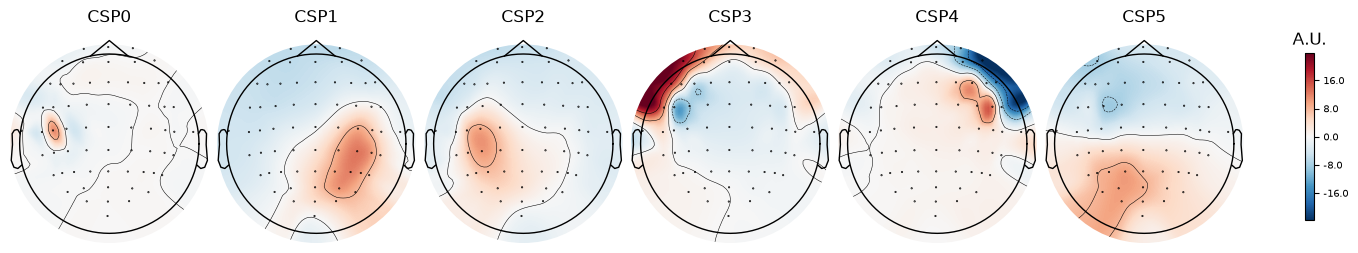

In [17]:
# Graficar ÚNICAMENTE los 6 componentes seleccionados por CSP
csp.plot_patterns(
    raw.info, 
    components=[0, 1, 2, 3, 4, 5], 
    ch_type='eeg', 
    units='A.U.', 
    size=1.5
);